# Wide Training Example - Puebla

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import matplotlib.pyplot as plt
from PIL import Image


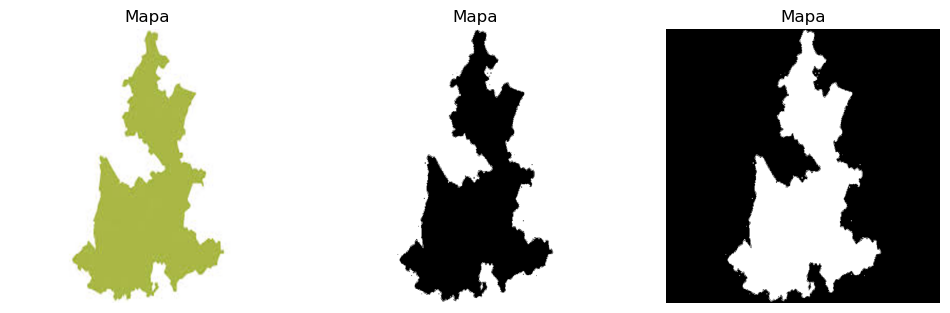

/home/gustavo/.local/lib/python3.12/site-packages/torch/autograd/graph.py:829: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 1: Loss 0.6557
Epoch 2: Loss 0.6064
Epoch 3: Loss 0.5387
Epoch 4: Loss 0.4577
Epoch 5: Loss 0.3822
Epoch 6: Loss 0.3304
Epoch 7: Loss 0.2961
Epoch 8: Loss 0.2781
Epoch 9: Loss 0.2676
Epoch 10: Loss 0.2582
Epoch 11: Loss 0.2545
Epoch 12: Loss 0.2473
Epoch 13: Loss 0.2414
Epoch 14: Loss 0.2374
Epoch 15: Loss 0.2330
Epoch 16: Loss 0.2302
Epoch 17: Loss 0.2279
Epoch 18: Loss 0.2229
Epoch 19: Loss 0.2218
Epoch 20: Loss 0.2196
Epoch 21: Loss 0.2176
Epoch 22: Loss 0.2135
Epoch 23: Loss 0.2148
Epoch 24: Loss 0.2132
Epoch 25: Loss 0.2117
Epoch 26: Loss 0.2089
Epoch 27: Loss 0.2077
Epoch 28: Loss 0.2056
Epoch 29: Loss 0.2059
Epoch 30: Loss 0.2033
Epoch 31: Loss 0.2023
Epoch 32: Loss 0.2005
Epoch 33: Loss 0.2013
Epoch 34: Loss 0.2026
Epoch 35: Loss 0.1994
Epoch 36: Loss 0.1975
Epoch 37: Loss 0.1971
Epoch 38: Loss 0.1943
Epoch 39: Loss 0.1931
Epoch 40: Loss 0.1916
Epoch 41: Loss 0.1922
Epoch 42: Loss 0.1929
Epoch 43: Loss 0.1898
Epoch 44: Loss 0.1900
Epoch 45: Loss 0.1920
Epoch 46: Loss 0.18

In [2]:
img_path = "/home/gustavo/Downloads/mapaPuebla.png"  
img = Image.open(img_path).convert("RGB")
img = img.resize((600, 600))  
img = np.array(img)
H, W = img.shape[:2]


# Coordenadas
def to_norm_coords(xs, ys, W, H):
    xs = xs.astype(np.float32); ys = ys.astype(np.float32)
    x_norm = xs/(W/2.0) - 1.0
    y_norm = (H - ys)/(H/2.0) - 1.0
    return np.stack([x_norm, y_norm], axis=1)

def mask_by_color(img_rgb, color_rgb, tol=30):
    diff = (img_rgb.astype(np.int16) - np.array(color_rgb, dtype=np.int16))
    dist2 = (diff**2).sum(axis=-1)
    return dist2 < (tol*tol)

def coords_from_mask(mask, W, H):
    ys, xs = np.where(mask)
    return to_norm_coords(xs, ys, W, H)

# Contraste 
PUEBLA_COLOR = [200, 50, 50]
puebla_mask = mask_by_color(img, PUEBLA_COLOR, tol=35)
gray = img.mean(axis=2)
dark_lines = gray < 40
not_puebla_mask = (~puebla_mask) & (~dark_lines)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img); plt.title("Mapa"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(puebla_mask, cmap="gray"); plt.title("Mapa"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(not_puebla_mask, cmap="gray"); plt.title("Mapa"); plt.axis("off")
plt.show()

puebla_coords_all = coords_from_mask(puebla_mask, W, H)
other_coords_all  = coords_from_mask(not_puebla_mask, W, H)

np.random.seed(73)
num_points_to_sample = 2000
p_idx = np.random.choice(len(puebla_coords_all), num_points_to_sample, replace=False)
o_idx = np.random.choice(len(other_coords_all), num_points_to_sample, replace=False)
X_sample = np.vstack([other_coords_all[o_idx], puebla_coords_all[p_idx]]).astype(np.float32)
y_sample = np.concatenate([np.zeros(num_points_to_sample), np.ones(num_points_to_sample)]).astype(np.int64)

X_tensor = torch.from_numpy(X_sample)
y_tensor = torch.from_numpy(y_sample)

class PueblaNet(nn.Module):
    def __init__(self, hidden_layers=[80]):
        super().__init__()
        layers = [nn.Linear(2, hidden_layers[0]), nn.ReLU()]
        for i in range(len(hidden_layers)-1):
            layers += [nn.Linear(hidden_layers[i], hidden_layers[i+1]), nn.ReLU()]
        layers += [nn.Linear(hidden_layers[-1], 2)]
        self.model = nn.Sequential(*layers)
    def forward(self, x):
        return self.model(x)


# Entrenamiento
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

model = PueblaNet([40])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

for epoch in range(50):
    model.train()
    epoch_loss = 0
    for Xb, yb in dataloader:
        outputs = model(Xb)
        loss = criterion(outputs, yb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}: Loss {epoch_loss/len(dataloader):.4f}")

def viz_decision_boundary(model, W, H, res=100):
    xs = np.linspace(-1,1,res)
    ys = np.linspace(-1,1,res)
    XX, YY = np.meshgrid(xs, ys)
    grid = np.stack([XX,YY], axis=-1).reshape(-1,2).astype(np.float32)
    with torch.no_grad():
        logits = model(torch.from_numpy(grid))
        labels = logits.argmax(1).numpy().reshape(res,res)
    plt.imshow(np.array(Image.fromarray(img).resize((res,res))), extent=[0,W,H,0])
    plt.imshow(np.flipud(labels), alpha=0.5, extent=[0,W,H,0], cmap="viridis")
    plt.show()


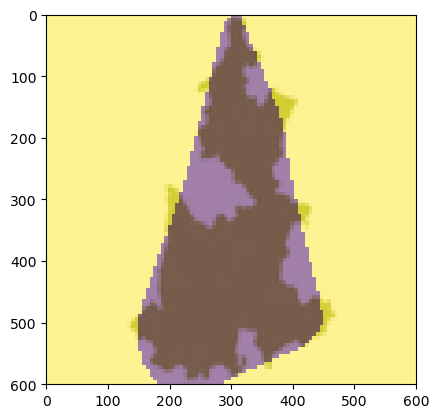

In [3]:
viz_decision_boundary(model, W, H)

## Guardar salida

In [4]:
from pathlib import Path

def guardar_frontera(model, img, W, H, res=150,
                     out_path="/home/gustavo/Downloads/frontera_decision.png",
                     alpha=0.5):
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)

    xs = np.linspace(-1, 1, res)
    ys = np.linspace(-1, 1, res)
    XX, YY = np.meshgrid(xs, ys)
    grid = np.stack([XX, YY], axis=-1).reshape(-1, 2).astype(np.float32)

    with torch.no_grad():
        logits = model(torch.from_numpy(grid))
        labels = logits.argmax(1).numpy().reshape(res, res)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(np.array(Image.fromarray(img).resize((res, res))), extent=[0, W, H, 0])
    ax.imshow(np.flipud(labels), alpha=alpha, extent=[0, W, H, 0], cmap="viridis")
    ax.set_xticks([]); ax.set_yticks([])
    fig.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

guardar_frontera(model, img, W, H)